# Lab Task 02 — Effect of Image Filtering on Skin-Lesion Classification

Investigates how 5 spatial-domain filters (Average, Gaussian, Median, Sharpening, Sobel)
affect classification performance, compared against an unfiltered baseline, across the
**3 best pretrained models identified in Lab Activity 1 (Task 01)**:

| Rank | Model | Task 01 Accuracy |
|---|---|---|
| 1 | VGG16 | 66.25% |
| 2 | ResNet101 | 65.00% |
| 3 | AlexNet | 63.75% |

Dataset: **HAM10000** (Kaggle: `kmader/skin-cancer-mnist-ham10000`) — download it yourself,
unzip, upload to Google Drive (no Kaggle API used here, same as Task 01's notebook).

Sections: Dataset preparation → Filtering → Model loading → Training → Evaluation →
Visualization → Comparative analysis.

GPU runtime recommended (Runtime → Change runtime type → T4 GPU).

## 1. Install dependencies

In [ ]:
!pip install -q opencv-python-headless


## 2. Dataset — mount Drive and set the path

Download HAM10000 from Kaggle (`kmader/skin-cancer-mnist-ham10000`), unzip it, and upload
the folder to your Google Drive. It should contain `HAM10000_metadata.csv` and the two
image-part folders. Set `DATA_ROOT` below to point at that folder.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [ ]:

DATA_ROOT = "/kaggle/input/skin-cancer-mnist-ham10000"

import os
print("Contents of DATA_ROOT:", os.listdir(DATA_ROOT))


Contents of DATA_ROOT: ['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']


## 3. Config

In [ ]:
import os

METADATA_CSV = os.path.join(DATA_ROOT, "HAM10000_metadata.csv")
IMAGE_DIRS = [
    os.path.join(DATA_ROOT, "HAM10000_images_part_1"),
    os.path.join(DATA_ROOT, "HAM10000_images_part_2"),
]
OUTPUT_DIR = "./results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Class subset (edit to run on the full 7 classes if you have time/compute) ---
# nv=melanocytic nevi, mel=melanoma, bkl=benign keratosis-like, bcc=basal cell carcinoma
CLASS_SUBSET = ["nv", "mel", "bkl", "bcc"]

VAL_RATIO = 0.10
TEST_RATIO = 0.10
RANDOM_SEED = 42

IMAGE_SIZE = 160
BATCH_SIZE = 64
FEATURE_EXTRACT_EPOCHS = 1     # kept low: 3 models x 6 conditions = 18 full training runs
FINE_TUNE_EPOCHS = 2           # bump up once the pipeline is confirmed working end-to-end
LEARNING_RATE = 1e-4
NUM_WORKERS = 2

# The 3 best models from Task 01 (Lab Activity 1), ranked by accuracy
BEST_MODELS = ["vgg16", "resnet101", "alexnet"]

# The 5 filters required by Task 02, plus "none" for the baseline
FILTERS = ["none", "average", "gaussian", "median", "sharpen", "sobel"]

import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print("Best models (from Task 01):", BEST_MODELS)
print("Class subset:", CLASS_SUBSET)


Using device: cuda
Best models (from Task 01): ['vgg16', 'resnet101', 'alexnet']
Class subset: ['nv', 'mel', 'bkl', 'bcc']


## 4. Dataset preparation — load, filter to class subset, stratified split

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader


def _find_image_path(image_id):
    for d in IMAGE_DIRS:
        candidate = os.path.join(d, image_id + ".jpg")
        if os.path.exists(candidate):
            return candidate
    return None


def load_filtered_metadata():
    df = pd.read_csv(METADATA_CSV)
    df = df[df["dx"].isin(CLASS_SUBSET)].copy()
    df["path"] = df["image_id"].apply(_find_image_path)
    missing = df["path"].isna().sum()
    if missing:
        print(f"[warning] {missing} images listed in metadata were not found on disk - dropping them.")
        df = df.dropna(subset=["path"])
    df["label"] = df["dx"].astype("category")
    df["label_idx"] = df["label"].cat.codes
    return df, list(df["label"].cat.categories)


def stratified_split(df):
    train_df, temp_df = train_test_split(
        df, test_size=(VAL_RATIO + TEST_RATIO), stratify=df["label_idx"], random_state=RANDOM_SEED,
    )
    relative_val = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
    val_df, test_df = train_test_split(
        temp_df, test_size=(1 - relative_val), stratify=temp_df["label_idx"], random_state=RANDOM_SEED,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


metadata_df, CLASSES = load_filtered_metadata()
NUM_CLASSES = len(CLASSES)
print("Classes used:", CLASSES)
print("Class distribution:\n", metadata_df["dx"].value_counts())

train_df, val_df, test_df = stratified_split(metadata_df)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")


Classes used: ['bcc', 'bkl', 'mel', 'nv']
Class distribution:
 dx
nv     6705
mel    1113
bkl    1099
bcc     514
Name: count, dtype: int64
Train: 7544  Val: 943  Test: 944


### Class distribution plot (required in Additional Analysis)

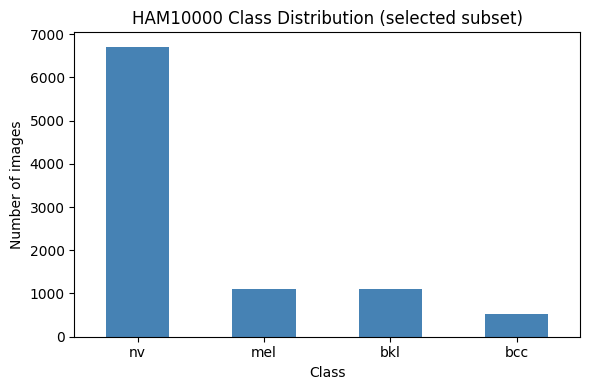

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
metadata_df["dx"].value_counts().plot(kind="bar", color="steelblue")
plt.title("HAM10000 Class Distribution (selected subset)")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_distribution.png"), dpi=150)
plt.show()


## 5. Image filtering

Implements the 5 required spatial-domain filters plus a "none" passthrough for the baseline.
Each filter operates on the resized image (before normalization) so every model sees the
same preprocessing pipeline aside from the filter itself.

In [ ]:
import cv2


def apply_filter(np_img, filter_name):
    """np_img: HxWx3 uint8 RGB array. Returns a filtered HxWx3 uint8 RGB array."""
    if filter_name == "none":
        return np_img
    elif filter_name == "average":
        return cv2.blur(np_img, (5, 5))
    elif filter_name == "gaussian":
        return cv2.GaussianBlur(np_img, (5, 5), 0)
    elif filter_name == "median":
        return cv2.medianBlur(np_img, 5)
    elif filter_name == "sharpen":
        kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
        return cv2.filter2D(np_img, -1, kernel)
    elif filter_name == "sobel":
        gray = cv2.cvtColor(np_img, cv2.COLOR_RGB2GRAY)
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        magnitude = np.sqrt(sobelx ** 2 + sobely ** 2)
        magnitude = np.clip(magnitude / magnitude.max() * 255, 0, 255).astype(np.uint8)
        return cv2.cvtColor(magnitude, cv2.COLOR_GRAY2RGB)
    else:
        raise ValueError(f"Unknown filter: {filter_name}")


class ApplyFilterTransform:
    """Torchvision-compatible transform: takes a resized PIL image, applies the
    named filter, returns a PIL image."""

    def __init__(self, filter_name):
        self.filter_name = filter_name

    def __call__(self, pil_img):
        np_img = np.array(pil_img.convert("RGB"))
        filtered = apply_filter(np_img, self.filter_name)
        return Image.fromarray(filtered)


### Original vs. filtered image examples (required in Additional Analysis)

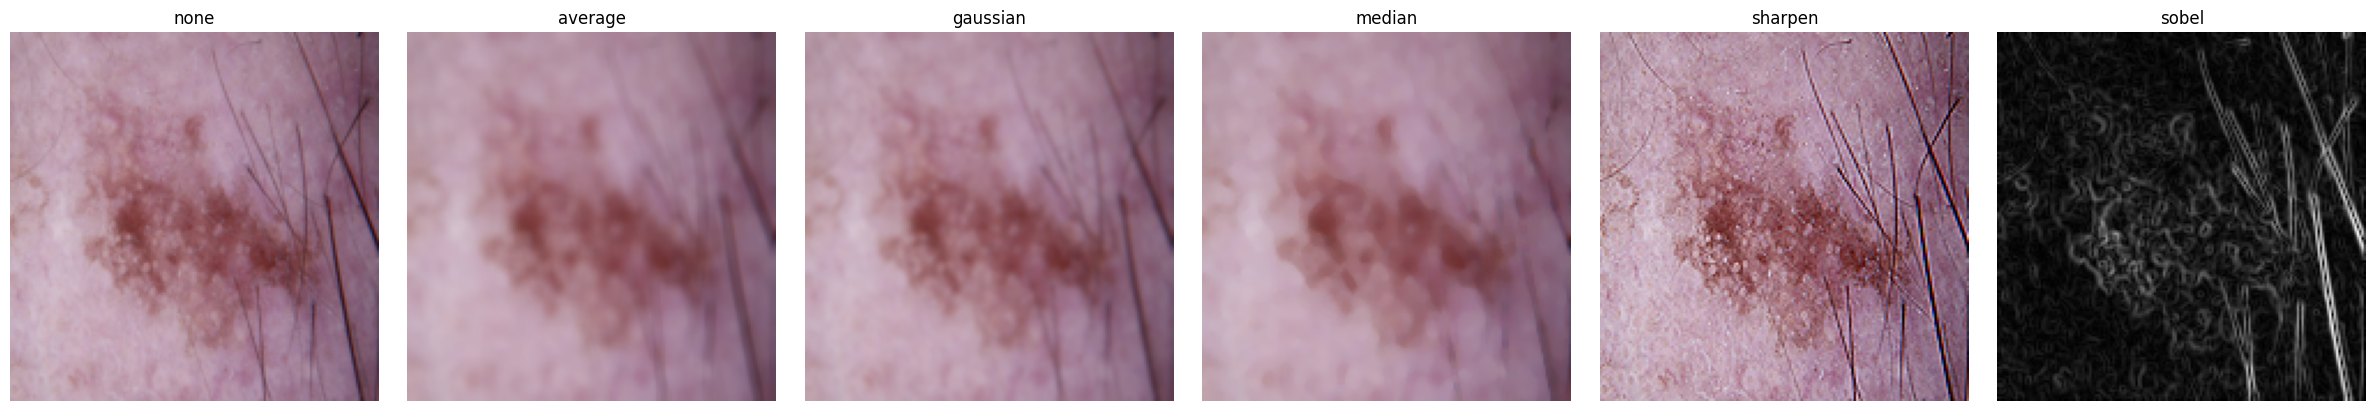

In [ ]:
import torchvision.transforms as T

sample_path = train_df.iloc[0]["path"]
sample_img = Image.open(sample_path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))

fig, axes = plt.subplots(1, len(FILTERS), figsize=(4 * len(FILTERS), 4))
for ax, filt in zip(axes, FILTERS):
    filtered_img = ApplyFilterTransform(filt)(sample_img)
    ax.imshow(filtered_img)
    ax.set_title(filt)
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "filter_examples.png"), dpi=150)
plt.show()


## 6. Transforms and Dataset class (filter is injected per experiment)

In [ ]:
def get_transforms(filter_name, train=True):
    normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    base = [T.Resize((IMAGE_SIZE, IMAGE_SIZE)), ApplyFilterTransform(filter_name)]
    if train:
        base += [
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.5),
            T.RandomAffine(degrees=0, translate=(0.2, 0.2), shear=0.2),
        ]
    base += [T.ToTensor(), normalize]
    return T.Compose(base)


class HAM10000Subset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, int(row["label_idx"])


def make_loaders(filter_name):
    """Builds train/val/test DataLoaders for one filter condition. Same split
    (train_df/val_df/test_df) is reused every time - only the filter changes."""
    train_ds = HAM10000Subset(train_df, transform=get_transforms(filter_name, train=True))
    val_ds = HAM10000Subset(val_df, transform=get_transforms(filter_name, train=False))
    test_ds = HAM10000Subset(test_df, transform=get_transforms(filter_name, train=False))
    return (
        DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS),
        DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
        DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
    )


## 7. Model loading — only the 3 best models from Task 01

In [ ]:
import torch.nn as nn
from torchvision import models


def build_model(name, num_classes):
    if name == "alexnet":
        m = models.alexnet(weights="IMAGENET1K_V1")
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
    elif name == "vgg16":
        m = models.vgg16(weights="IMAGENET1K_V1")
        m.classifier[6] = nn.Linear(m.classifier[6].in_features, num_classes)
    elif name == "resnet101":
        m = models.resnet101(weights="IMAGENET1K_V2")
        m.fc = nn.Linear(m.fc.in_features, num_classes)
    else:
        raise ValueError(f"Unknown model: {name}")
    return m


def set_backbone_trainable(model, trainable: bool):
    for param in model.parameters():
        param.requires_grad = trainable
    last_layer = list(model.children())[-1]
    for param in last_layer.parameters():
        param.requires_grad = True


## 8. Training and evaluation (baseline experiment logic, reused for every filter)

In [ ]:
import copy
import time
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, balanced_accuracy_score, confusion_matrix, classification_report,
)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total_samples += images.size(0)
    return total_loss / total_samples, total_correct / total_samples


def evaluate(model, loader):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            all_labels.extend(labels.numpy())
            all_preds.extend(probs.argmax(axis=1))
            all_probs.extend(probs)
    all_labels, all_preds, all_probs = np.array(all_labels), np.array(all_preds), np.array(all_probs)

    metrics = {
        "Accuracy": round(accuracy_score(all_labels, all_preds) * 100, 2),
        "Precision": round(precision_score(all_labels, all_preds, average="weighted", zero_division=0) * 100, 2),
        "Recall": round(recall_score(all_labels, all_preds, average="weighted", zero_division=0) * 100, 2),
        "F1-score": round(f1_score(all_labels, all_preds, average="weighted", zero_division=0) * 100, 2),
        "Macro-F1": round(f1_score(all_labels, all_preds, average="macro", zero_division=0) * 100, 2),
        "Balanced Accuracy": round(balanced_accuracy_score(all_labels, all_preds) * 100, 2),
    }
    try:
        metrics["AUC"] = round(roc_auc_score(all_labels, all_probs, multi_class="ovr", average="weighted") * 100, 2)
    except ValueError:
        metrics["AUC"] = float("nan")

    cm = confusion_matrix(all_labels, all_preds)
    per_class_report = classification_report(all_labels, all_preds, target_names=CLASSES, output_dict=True, zero_division=0)
    return metrics, cm, per_class_report


def train_one_experiment(model_name, filter_name):
    print(f"\n=== Training {model_name} | filter={filter_name} ===")
    train_loader, val_loader, test_loader = make_loaders(filter_name)
    model = build_model(model_name, NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

    # Stage 1: feature extraction
    set_backbone_trainable(model, trainable=False)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
    for epoch in range(FEATURE_EXTRACT_EPOCHS):
        run_epoch(model, train_loader, criterion, optimizer)

    # Stage 2: fine-tune, with history tracked for curves
    set_backbone_trainable(model, trainable=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    best_val_acc, best_state = 0.0, copy.deepcopy(model.state_dict())
    for epoch in range(FINE_TUNE_EPOCHS):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if val_acc > best_val_acc:
            best_val_acc, best_state = val_acc, copy.deepcopy(model.state_dict())
        print(f"  [epoch {epoch+1}/{FINE_TUNE_EPOCHS}] train_acc={train_acc:.3f} val_acc={val_acc:.3f}")

    model.load_state_dict(best_state)
    metrics, cm, per_class_report = evaluate(model, test_loader)
    return metrics, history, cm, per_class_report


## 9. Run all experiments — 3 models × (baseline + 5 filters) = 18 runs

Results are saved incrementally so a crash partway through doesn't lose earlier runs.
Histories and confusion matrices are kept in memory for the visualization section below.

In [ ]:
results = []
histories = {}
confusion_matrices = {}
per_class_reports = {}

for model_name in BEST_MODELS:
    for filter_name in FILTERS:
        start = time.time()
        metrics, history, cm, per_class_report = train_one_experiment(model_name, filter_name)
        elapsed_min = round((time.time() - start) / 60, 1)

        display_filter = "No Filter" if filter_name == "none" else filter_name.capitalize()
        row = {"Model": model_name, "Filter": display_filter, **metrics, "Train Time (min)": elapsed_min}
        results.append(row)

        key = (model_name, filter_name)
        histories[key] = history
        confusion_matrices[key] = cm
        per_class_reports[key] = per_class_report

        pd.DataFrame(results).to_csv(os.path.join(OUTPUT_DIR, "task02_filter_comparison_results.csv"), index=False)

results_df = pd.DataFrame(results)
results_df



=== Training vgg16 | filter=none ===
  [epoch 1/2] train_acc=0.764 val_acc=0.786
  [epoch 2/2] train_acc=0.809 val_acc=0.826

=== Training vgg16 | filter=average ===
  [epoch 1/2] train_acc=0.760 val_acc=0.815
  [epoch 2/2] train_acc=0.796 val_acc=0.777

=== Training vgg16 | filter=gaussian ===
  [epoch 1/2] train_acc=0.767 val_acc=0.813
  [epoch 2/2] train_acc=0.806 val_acc=0.832

=== Training vgg16 | filter=median ===
  [epoch 1/2] train_acc=0.759 val_acc=0.810
  [epoch 2/2] train_acc=0.799 val_acc=0.817

=== Training vgg16 | filter=sharpen ===
  [epoch 1/2] train_acc=0.769 val_acc=0.806
  [epoch 2/2] train_acc=0.816 val_acc=0.846

=== Training vgg16 | filter=sobel ===
  [epoch 1/2] train_acc=0.725 val_acc=0.736
  [epoch 2/2] train_acc=0.748 val_acc=0.751

=== Training resnet101 | filter=none ===
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:00<00:00, 186MB/s]


  [epoch 1/2] train_acc=0.766 val_acc=0.840
  [epoch 2/2] train_acc=0.861 val_acc=0.859

=== Training resnet101 | filter=average ===
  [epoch 1/2] train_acc=0.774 val_acc=0.838
  [epoch 2/2] train_acc=0.850 val_acc=0.847

=== Training resnet101 | filter=gaussian ===
  [epoch 1/2] train_acc=0.773 val_acc=0.832
  [epoch 2/2] train_acc=0.855 val_acc=0.838

=== Training resnet101 | filter=median ===
  [epoch 1/2] train_acc=0.766 val_acc=0.822
  [epoch 2/2] train_acc=0.842 val_acc=0.848

=== Training resnet101 | filter=sharpen ===
  [epoch 1/2] train_acc=0.770 val_acc=0.824
  [epoch 2/2] train_acc=0.858 val_acc=0.864

=== Training resnet101 | filter=sobel ===
  [epoch 1/2] train_acc=0.726 val_acc=0.754
  [epoch 2/2] train_acc=0.774 val_acc=0.783

=== Training alexnet | filter=none ===
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 148MB/s]


  [epoch 1/2] train_acc=0.787 val_acc=0.801
  [epoch 2/2] train_acc=0.811 val_acc=0.821

=== Training alexnet | filter=average ===
  [epoch 1/2] train_acc=0.784 val_acc=0.793
  [epoch 2/2] train_acc=0.804 val_acc=0.796

=== Training alexnet | filter=gaussian ===
  [epoch 1/2] train_acc=0.781 val_acc=0.778
  [epoch 2/2] train_acc=0.805 val_acc=0.823

=== Training alexnet | filter=median ===
  [epoch 1/2] train_acc=0.786 val_acc=0.810
  [epoch 2/2] train_acc=0.807 val_acc=0.829

=== Training alexnet | filter=sharpen ===
  [epoch 1/2] train_acc=0.779 val_acc=0.806
  [epoch 2/2] train_acc=0.806 val_acc=0.831

=== Training alexnet | filter=sobel ===
  [epoch 1/2] train_acc=0.720 val_acc=0.738
  [epoch 2/2] train_acc=0.735 val_acc=0.749


,Model,Filter,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Accuracy,AUC,Train Time (min)
0,vgg16,No Filter,80.51,82.80,80.51,81.20,68.00,70.04,92.76,4.1
1,vgg16,Average,79.77,78.73,79.77,77.98,61.03,61.90,91.32,4.2
2,vgg16,Gaussian,80.83,80.85,80.83,79.22,64.09,66.04,91.79,4.1
3,vgg16,Median,81.04,79.33,81.04,78.75,62.22,57.58,91.35,4.4
4,vgg16,Sharpen,80.83,80.05,80.83,79.37,64.77,63.10,91.41,4.2
5,vgg16,Sobel,73.09,73.78,73.09,73.14,53.68,55.86,86.46,4.3
6,resnet101,No Filter,86.44,86.15,86.44,85.70,75.07,73.90,95.69,4.2
7,resnet101,Average,81.36,83.45,81.36,81.99,66.82,71.25,94.34,4.3
8,resnet101,Gaussian,85.17,85.67,85.17,85.29,73.03,72.81,95.74,4.2
9,resnet101,Median,83.58,83.64,83.58,83.60,71.36,72.13,94.57,4.6


## 10. Visualization

### Training/validation accuracy and loss curves
Pick any (model, filter) combination to plot — defaults to the baseline of the top model.

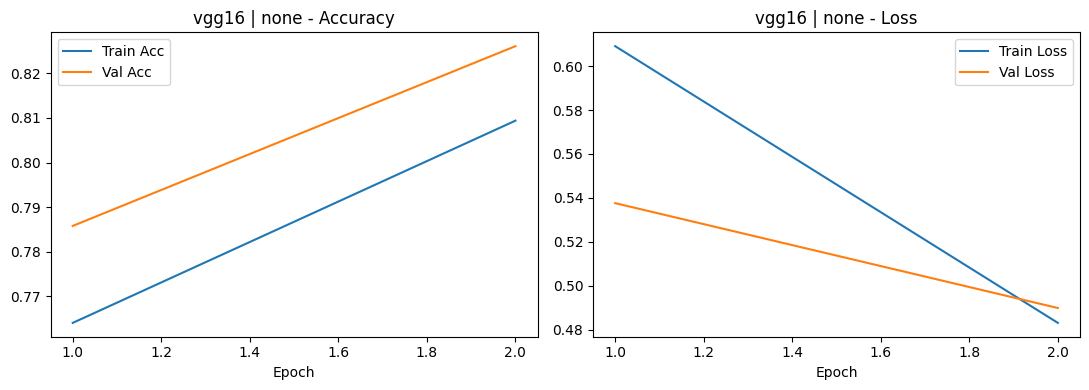

In [ ]:
def plot_history(model_name, filter_name):
    h = histories[(model_name, filter_name)]
    epochs = range(1, len(h["train_acc"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(epochs, h["train_acc"], label="Train Acc")
    axes[0].plot(epochs, h["val_acc"], label="Val Acc")
    axes[0].set_title(f"{model_name} | {filter_name} - Accuracy")
    axes[0].set_xlabel("Epoch"); axes[0].legend()
    axes[1].plot(epochs, h["train_loss"], label="Train Loss")
    axes[1].plot(epochs, h["val_loss"], label="Val Loss")
    axes[1].set_title(f"{model_name} | {filter_name} - Loss")
    axes[1].set_xlabel("Epoch"); axes[1].legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"curves_{model_name}_{filter_name}.png"), dpi=150)
    plt.show()


# Example: baseline curve for the top model. Change these to inspect any combination.
plot_history(BEST_MODELS[0], "none")


### Confusion matrices — full 3x6 grid (every model x every filter)

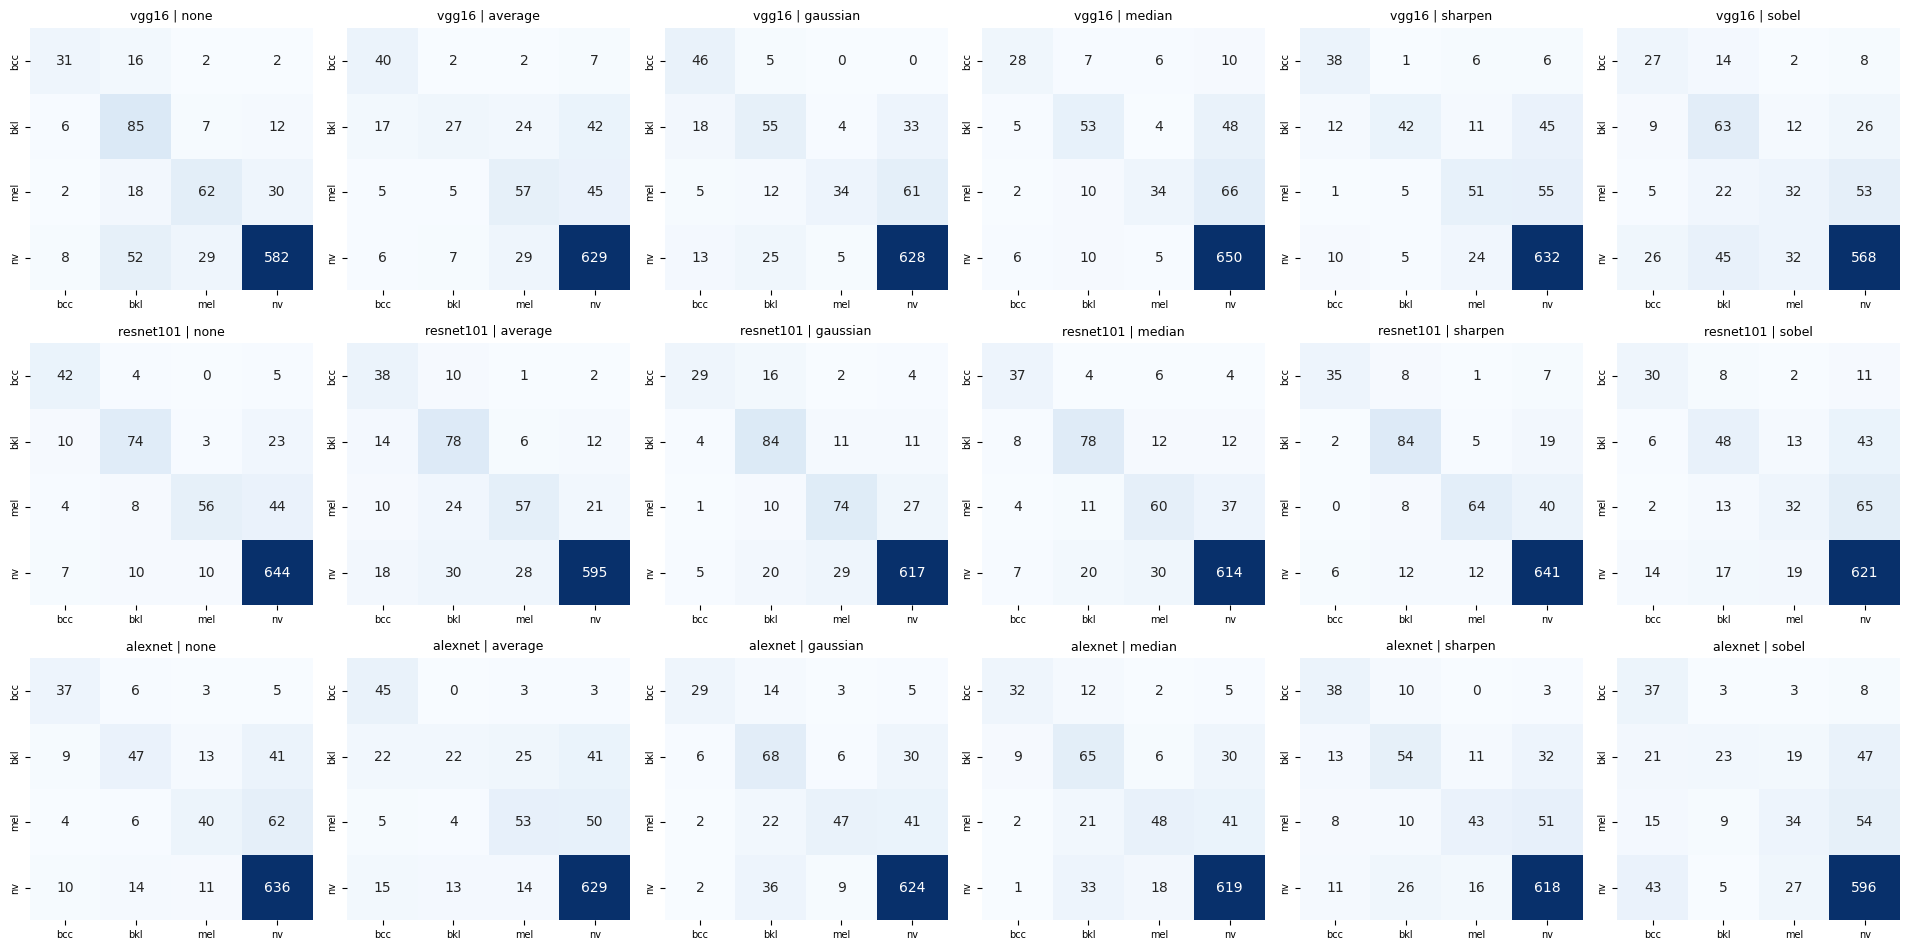

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(len(BEST_MODELS), len(FILTERS), figsize=(3.2 * len(FILTERS), 3.2 * len(BEST_MODELS)))
for i, model_name in enumerate(BEST_MODELS):
    for j, filter_name in enumerate(FILTERS):
        cm = confusion_matrices[(model_name, filter_name)]
        ax = axes[i][j] if len(BEST_MODELS) > 1 else axes[j]
        sns.heatmap(cm, annot=True, fmt="d", cbar=False, ax=ax,
                    xticklabels=CLASSES, yticklabels=CLASSES, cmap="Blues")
        ax.set_title(f"{model_name} | {filter_name}", fontsize=9)
        ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrices_grid.png"), dpi=150)
plt.show()


### Per-class precision, recall, F1-score (for one combination at a time)

In [ ]:
def show_per_class(model_name, filter_name):
    report = per_class_reports[(model_name, filter_name)]
    df = pd.DataFrame(report).transpose().loc[CLASSES, ["precision", "recall", "f1-score"]]
    return (df * 100).round(2)


# Example: per-class breakdown for the top model's baseline
show_per_class(BEST_MODELS[0], "none")


,precision,recall,f1-score
bcc,65.96,60.78,63.27
bkl,49.71,77.27,60.50
mel,62.00,55.36,58.49
nv,92.97,86.74,89.75


## 11. Comparative analysis

Pivot tables and deltas-from-baseline to answer the "which filter changes performance the
most" and "is the effect consistent across models" questions directly from the data.

In [ ]:
pivot_accuracy = results_df.pivot(index="Filter", columns="Model", values="Accuracy")
pivot_macro_f1 = results_df.pivot(index="Filter", columns="Model", values="Macro-F1")

print("Accuracy (%) - Model vs Filter")
display(pivot_accuracy)

print("\nMacro-F1 (%) - Model vs Filter")
display(pivot_macro_f1)

# Delta vs each model's own "No Filter" baseline
delta_rows = []
for model_name in BEST_MODELS:
    baseline_acc = results_df[(results_df["Model"] == model_name) & (results_df["Filter"] == "No Filter")]["Accuracy"].iloc[0]
    baseline_macro_f1 = results_df[(results_df["Model"] == model_name) & (results_df["Filter"] == "No Filter")]["Macro-F1"].iloc[0]
    for _, row in results_df[results_df["Model"] == model_name].iterrows():
        delta_rows.append({
            "Model": model_name,
            "Filter": row["Filter"],
            "Accuracy Delta": round(row["Accuracy"] - baseline_acc, 2),
            "Macro-F1 Delta": round(row["Macro-F1"] - baseline_macro_f1, 2),
        })
delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv(os.path.join(OUTPUT_DIR, "task02_deltas_vs_baseline.csv"), index=False)
delta_df


Accuracy (%) - Model vs Filter


Model,alexnet,resnet101,vgg16
Filter,,,
Average,79.34,81.36,79.77
Gaussian,81.36,85.17,80.83
Median,80.93,83.58,81.04
No Filter,80.51,86.44,80.51
Sharpen,79.77,87.29,80.83
Sobel,73.09,77.44,73.09



Macro-F1 (%) - Model vs Filter


Model,alexnet,resnet101,vgg16
Filter,,,
Average,59.05,66.82,61.03
Gaussian,65.75,73.03,64.09
Median,65.89,71.36,62.22
No Filter,63.15,75.07,68.00
Sharpen,62.85,77.29,64.77
Sobel,49.12,57.80,53.68


,Model,Filter,Accuracy Delta,Macro-F1 Delta
0,vgg16,No Filter,0.00,0.00
1,vgg16,Average,-0.74,-6.97
2,vgg16,Gaussian,0.32,-3.91
3,vgg16,Median,0.53,-5.78
4,vgg16,Sharpen,0.32,-3.23
5,vgg16,Sobel,-7.42,-14.32
6,resnet101,No Filter,0.00,0.00
7,resnet101,Average,-5.08,-8.25
8,resnet101,Gaussian,-1.27,-2.04
9,resnet101,Median,-2.86,-3.71


## 12. Download results

In [ ]:
from google.colab import files

for fname in ["task02_filter_comparison_results.csv", "task02_deltas_vs_baseline.csv",
              "class_distribution.png", "filter_examples.png", "confusion_matrices_grid.png"]:
    path = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(path):
        files.download(path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>